In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.spatial.transform import Rotation

csv_dir = Path("csvs")
csv_files = sorted(csv_dir.glob("*.csv"))


In [60]:
# ---- EDIT THIS LIST ----
CSV_NAMES = [
    "l1.csv",
    "l2.csv",
    "l3.csv",
    "l4.csv",
    "l5.csv",
    "s1.csv",
    "s2.csv",
    "s3.csv",
    "s4.csv",
    "s5.csv",

]
# -------------------------

csv_dir = Path("csvs")
bags = {}
for name in CSV_NAMES:
    f = csv_dir / f"{name}.csv"
    if not f.exists():
        print(f"[WARN] {f} not found, skipping")
        continue
    df = pd.read_csv(f)
    df["time"] = df["timestamp_sec"] + df["timestamp_nanosec"] * 1e-9
    df["time"] -= df["time"].iloc[0]
    quats = df[["orient_x", "orient_y", "orient_z", "orient_w"]].values
    df["yaw"] = Rotation.from_quat(quats).as_euler("xyz")[:, 2]
    bags[name] = df

print(f"Loaded {len(bags)}/{len(CSV_NAMES)} bag(s)")

[WARN] csvs/l1.csv.csv not found, skipping
[WARN] csvs/l2.csv.csv not found, skipping
[WARN] csvs/l3.csv.csv not found, skipping
[WARN] csvs/l4.csv.csv not found, skipping
[WARN] csvs/l5.csv.csv not found, skipping
[WARN] csvs/s1.csv.csv not found, skipping
[WARN] csvs/s2.csv.csv not found, skipping
[WARN] csvs/s3.csv.csv not found, skipping
[WARN] csvs/s4.csv.csv not found, skipping
[WARN] csvs/s5.csv.csv not found, skipping
Loaded 0/10 bag(s)


In [61]:
def plot_bag(name, title=None):
    df = pd.read_csv(Path("csvs") / f"{name}.csv")
    df["time"] = df["timestamp_sec"] + df["timestamp_nanosec"] * 1e-9
    df["time"] -= df["time"].iloc[0]
    quats = df[["orient_x", "orient_y", "orient_z", "orient_w"]].values
    df["yaw"] = Rotation.from_quat(quats).as_euler("xyz")[:, 2]

    display_title = title if title else name

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    axes[0].plot(df["pos_x"], df["pos_y"], linewidth=3)
    axes[0].scatter(df["pos_x"].iloc[0], df["pos_y"].iloc[0], marker="o", s=80, c="green", label="start", zorder=5)
    axes[0].scatter(df["pos_x"].iloc[-1], df["pos_y"].iloc[-1], marker="x", s=80, c="red", label="end", zorder=5)
    axes[0].set_xlabel("x (m)")
    axes[0].set_ylabel("y (m)")
    axes[0].set_title("Path (x vs y)")
    axes[0].set_aspect("equal")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    ax_x = axes[1]
    # ax_y = ax_x.twinx()
    ax_x.plot(df["time"], df["pos_x"], label="x", color="tab:blue", linewidth=3)
    ax_x.plot(df["time"], df["pos_y"], label="y", color="tab:orange", linewidth=3)
    ax_x.set_xlabel("time (s)")
    ax_x.set_ylabel("position (m)")
    # ax_y.plot(df["time"], np.degrees(df["yaw"]), label="yaw", color="tab:green", alpha=0.7, linewidth=3)
    # ax_y.set_ylabel("yaw (°)")
    ax_x.legend(loc="upper left")
    axes[1].set_title("Position & Heading over Time")
    ax_x.grid(True, alpha=0.3)

    fig.suptitle(display_title, fontsize=14)
    plt.tight_layout()
    plt.show()

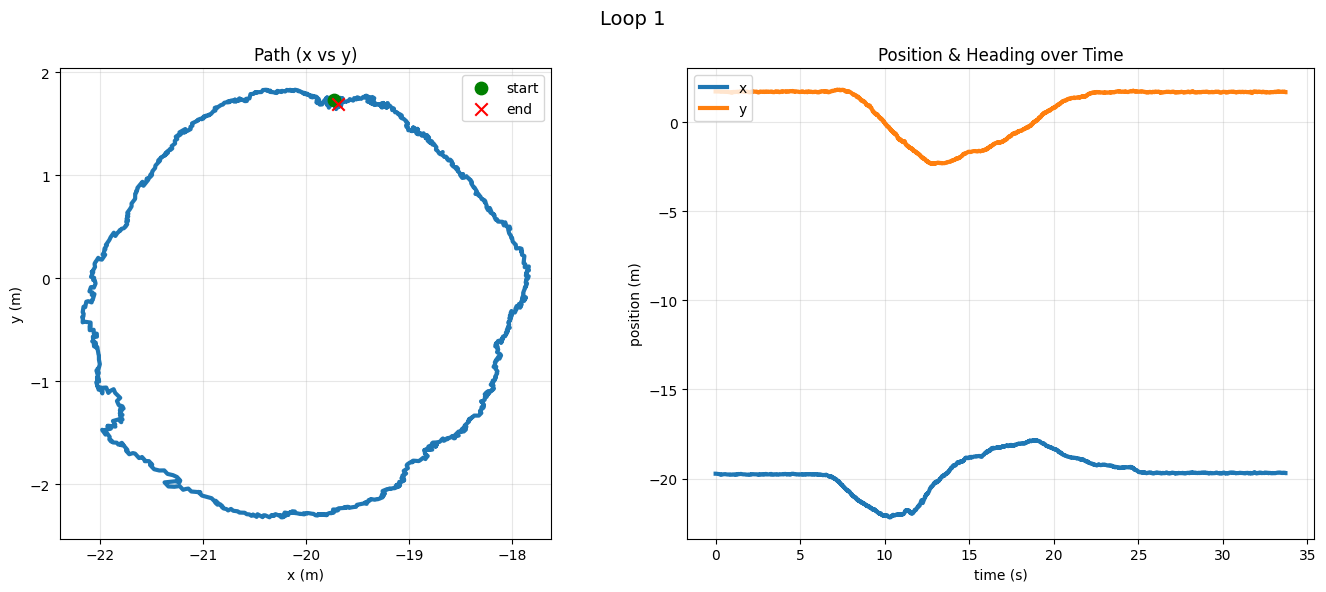

In [62]:
plot_bag("l1", title="Loop 1")


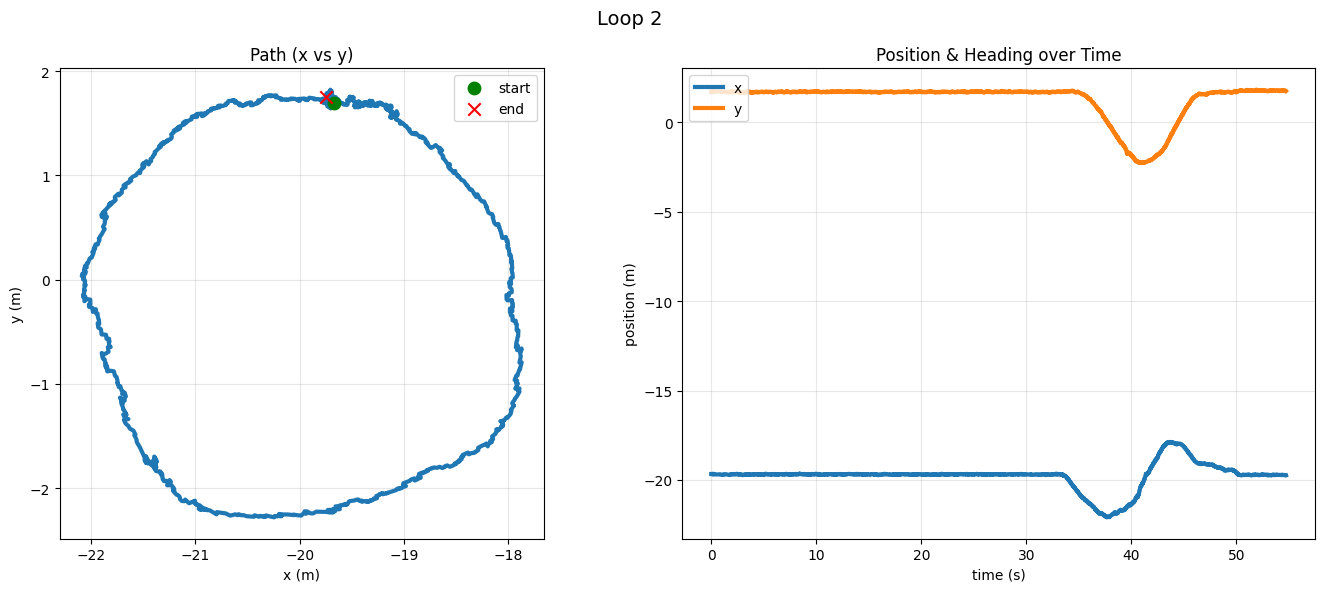

In [63]:
plot_bag("l2", title="Loop 2")

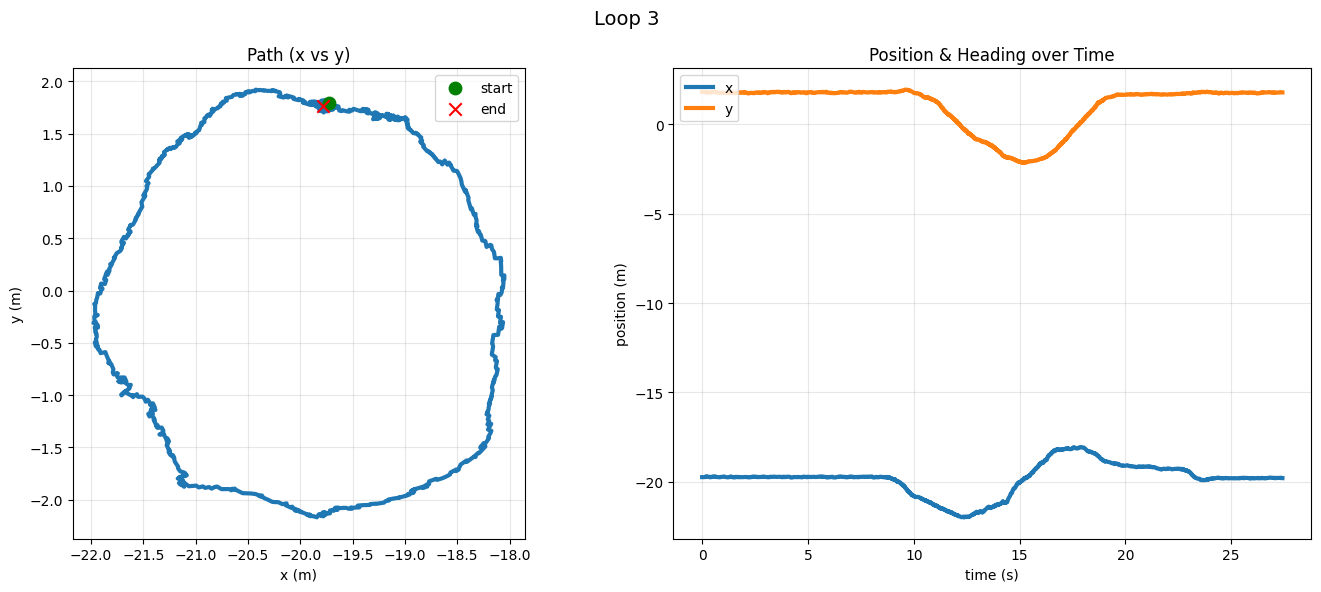

In [64]:
plot_bag("l3", title="Loop 3")

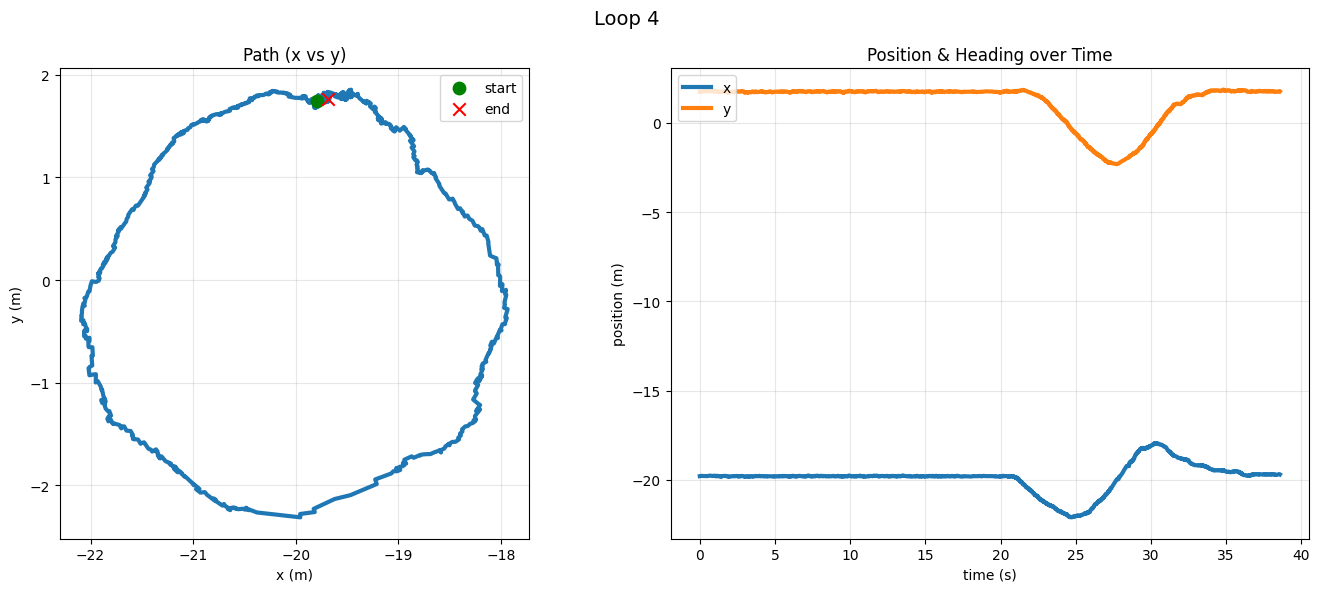

In [65]:
plot_bag("l4", title="Loop 4")

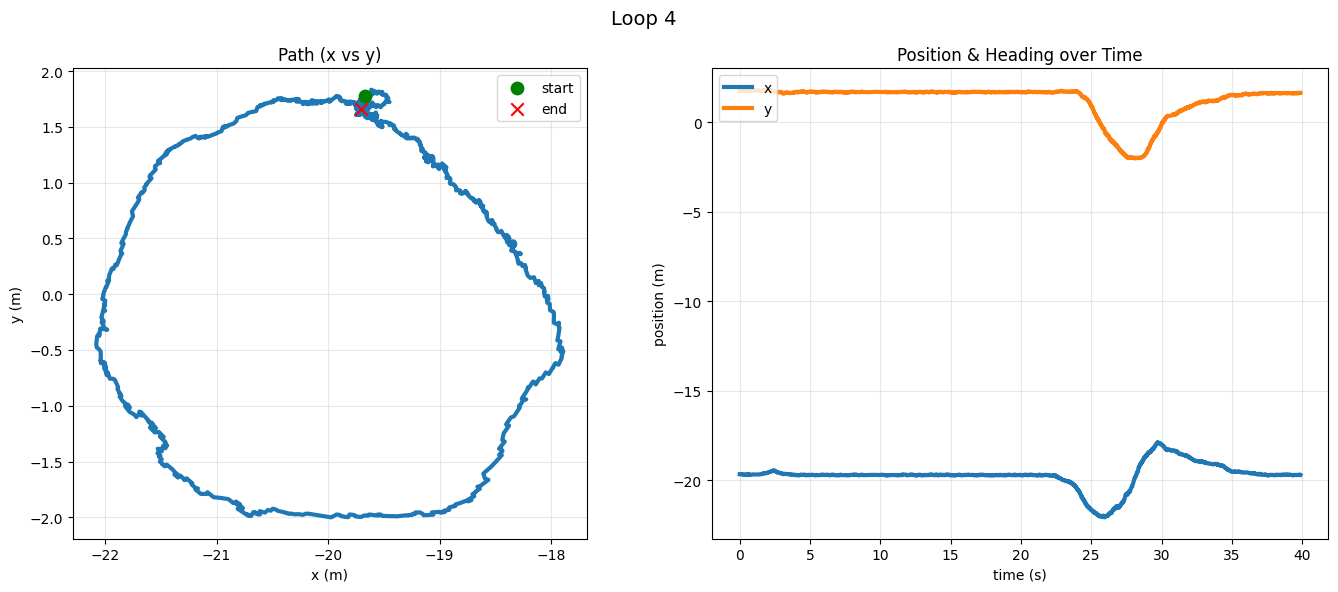

In [66]:
plot_bag("l5", title="Loop 4")

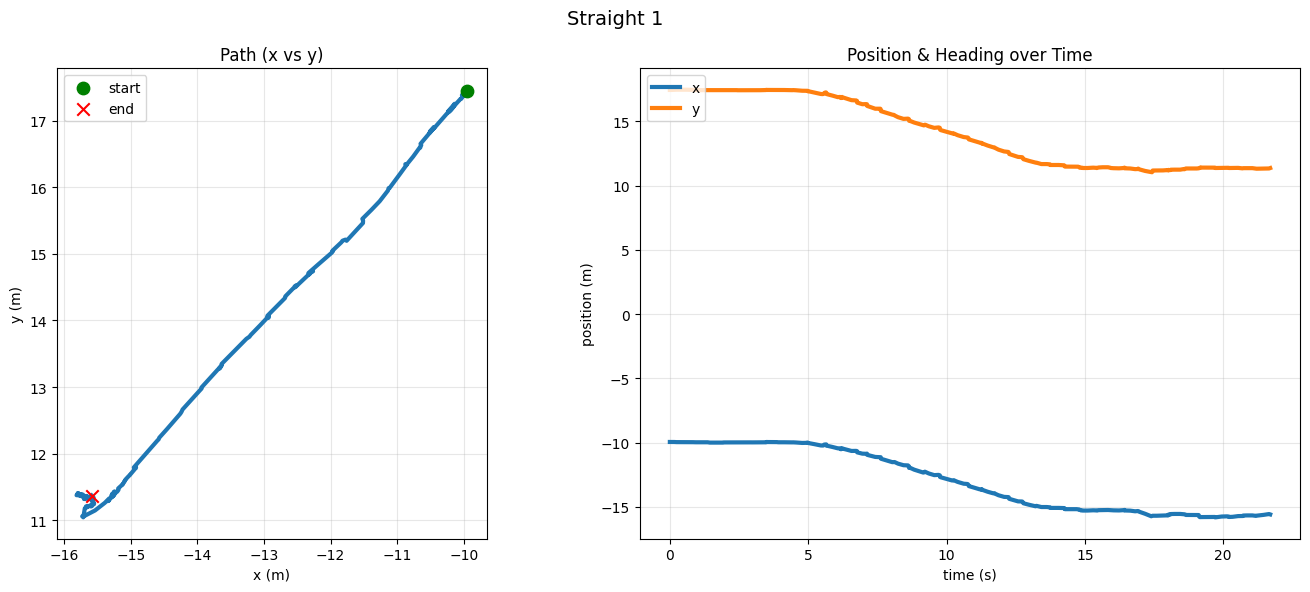

In [67]:
plot_bag("s1", title="Straight 1")


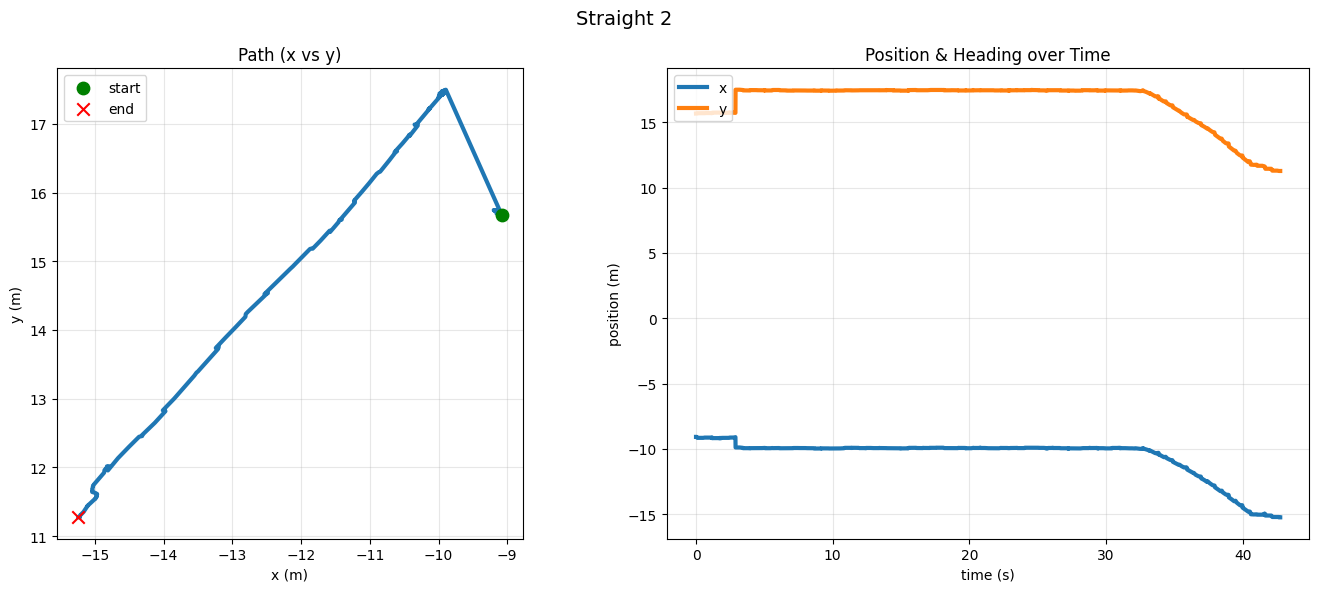

In [68]:
plot_bag("s2", title="Straight 2")


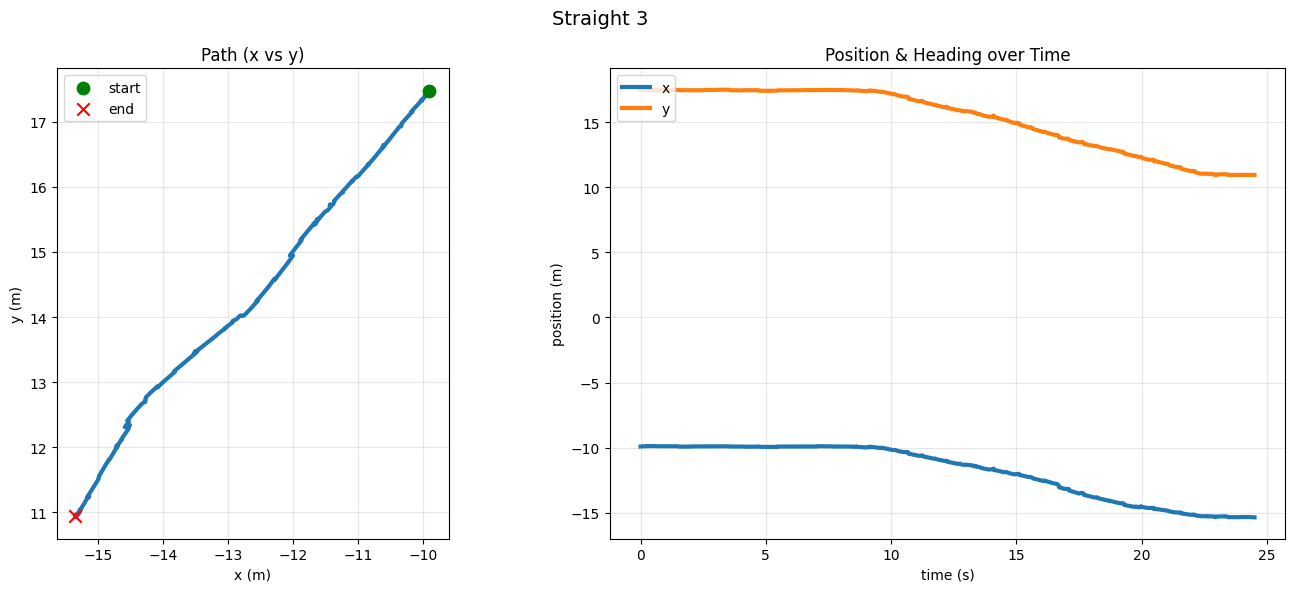

In [69]:
plot_bag("s3", title="Straight 3")

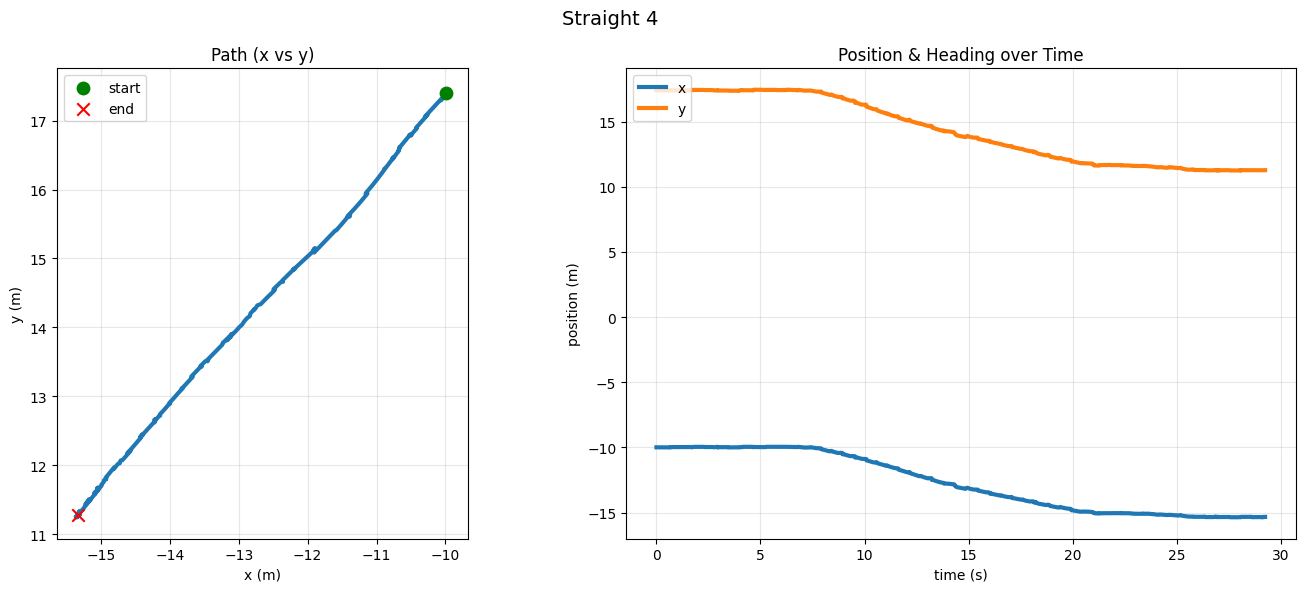

In [70]:
plot_bag("s4", title="Straight 4")

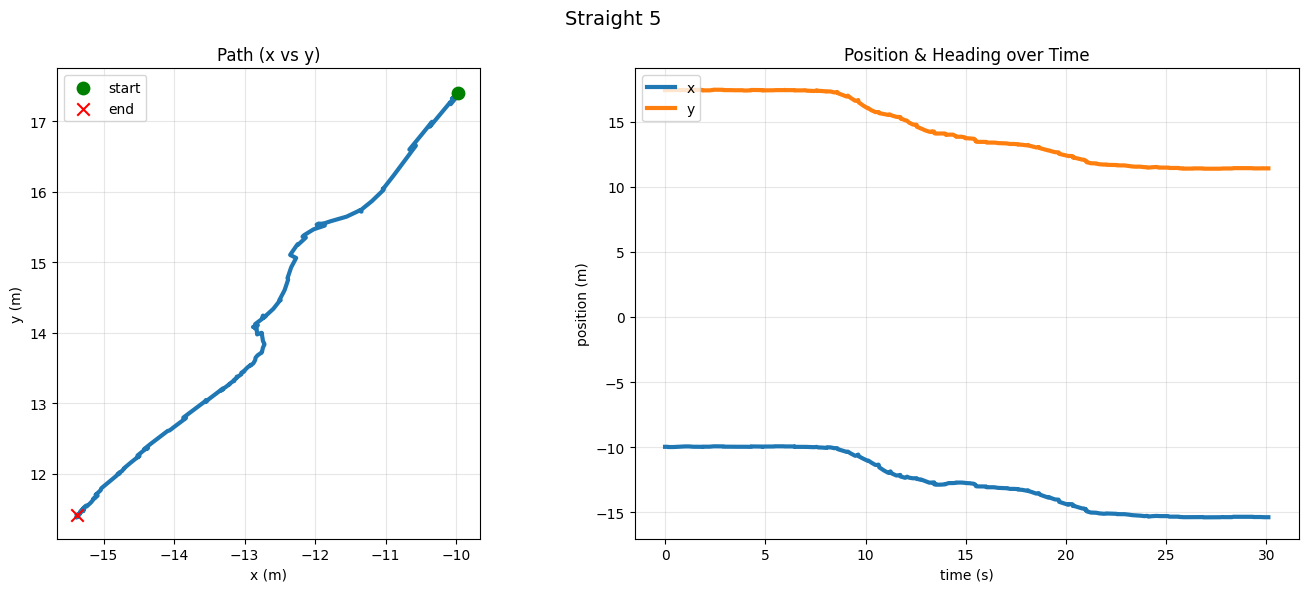

In [71]:
plot_bag("s5", title="Straight 5")

In [106]:
def plot_endpoints(names, titles=None, extra_points=None):
    fig, ax = plt.subplots(figsize=(8, 8))
    colors = plt.cm.tab10(np.arange(len(names)))

    for i, name in enumerate(names):
        df = pd.read_csv(Path("csvs") / f"{name}.csv")
        label = titles[i] if titles else name
        ax.scatter(df["pos_x"].iloc[-1], df["pos_y"].iloc[-1], s=100, color=colors[i], marker="o", label=label, zorder=5)

    if extra_points:
        for i, pt in enumerate(extra_points):
            ax.scatter(pt[0], pt[1], s=150, color=colors[i], marker="D", label=pt[2], zorder=6)

    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.set_title("Endpoints")
    ax.set_aspect("equal")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

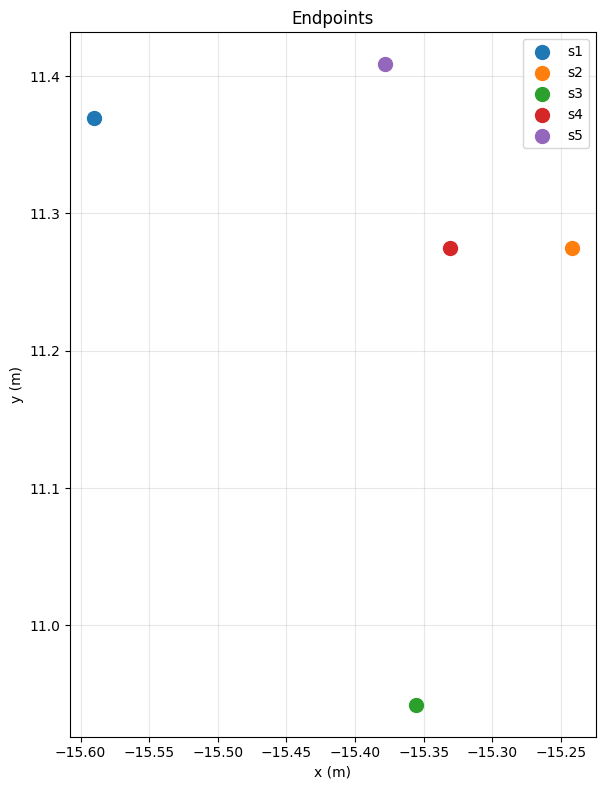

In [107]:
plot_endpoints(["s1","s2","s3","s4","s5"])

In [119]:
straight = ["s1","s2","s3","s4","s5"]
loop = ["l1","l2","l3","l4","l5"]
ground_truth = [
    (-15.53, 11.44),   # s1
    (-15.31, 11.26),   # s2
    (-15.37, 10.84),   # s3
    (-15.42, 11.33),   # s4
    (-15.28, 11.42),   # s5
]

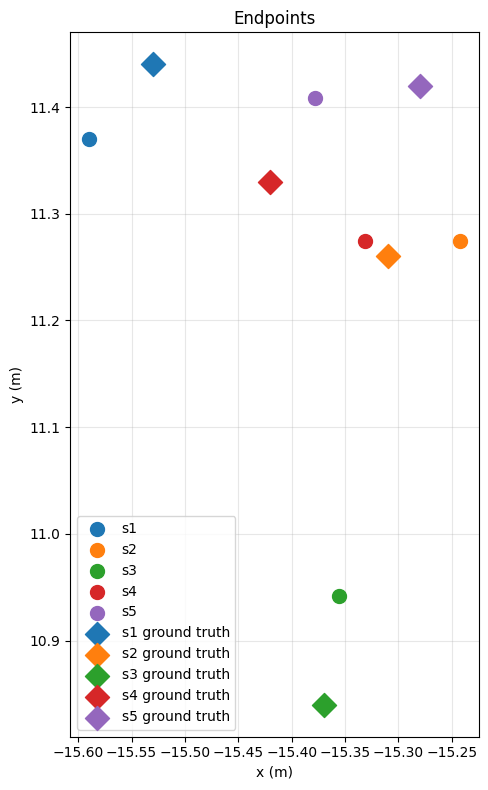

In [122]:
plot_endpoints(
    ["s1","s2","s3","s4","s5"],
    extra_points = [
    (-15.53, 11.44, "s1 ground truth"),   # s1
    (-15.31, 11.26, "s2 ground truth"),   # s2
    (-15.37, 10.84, "s3 ground truth"),   # s3
    (-15.42, 11.33, "s4 ground truth"),   # s4
    (-15.28, 11.42, "s5 ground truth"),   # s5
])

In [121]:
def compute_rmse(names, ground_truth):
    """
    names: list of csv stems, e.g. ["bag_1", "bag_2"]
    ground_truth: list of (x, y) tuples, same length as names

    Returns per-point error, RMSE, and endpoints.
    """
    errors = []
    endpoints = []

    print(f"{'Name':<30} {'Predicted':>20} {'Truth':>20} {'Error':>10}")
    print("-" * 85)

    for i, name in enumerate(names):
        df = pd.read_csv(Path("csvs") / f"{name}.csv")
        px, py = df["pos_x"].iloc[-1], df["pos_y"].iloc[-1]
        gx, gy = ground_truth[i]
        sq_err = (px - gx) ** 2 + (py - gy) ** 2
        errors.append(sq_err)
        endpoints.append((px, py))
        print(f"{name:<30} ({px:>8.3f}, {py:>8.3f}) ({gx:>8.3f}, {gy:>8.3f}) {np.sqrt(sq_err):>10.4f}")

    rmse = np.sqrt(np.mean(errors))
    print("-" * 85)
    print(f"{'RMSE':<72} {rmse:>10.4f}")
    print()
    print("Endpoints:")
    for i, name in enumerate(names):
        px, py = endpoints[i]
        print(f"  {name}: ({px:.3f}, {py:.3f})")

    return errors, rmse, endpoints

In [116]:
errors, avg, endpoints = compute_rmse(
    straight,
    ground_truth
)

Name                                      Predicted                Truth      Error
-------------------------------------------------------------------------------------
s1                             ( -15.590,   11.370) ( -15.527,   11.438)     0.0930
s2                             ( -15.242,   11.275) ( -15.309,   11.261)     0.0681
s3                             ( -15.356,   10.942) ( -15.372,   10.837)     0.1064
s4                             ( -15.331,   11.275) ( -15.418,   11.332)     0.1040
s5                             ( -15.378,   11.409) ( -15.283,   11.424)     0.0965
-------------------------------------------------------------------------------------
RMSE                                                                         0.0946

Endpoints:
  s1: (-15.590, 11.370)
  s2: (-15.242, 11.275)
  s3: (-15.356, 10.942)
  s4: (-15.331, 11.275)
  s5: (-15.378, 11.409)


In [117]:
def plot_start_vs_end(names, titles=None):
    """
    Plots start and end points for each bag and computes RMSE between them.
    """
    fig, ax = plt.subplots(figsize=(8, 8))
    errors = []

    print(f"{'Name':<30} {'Start':>20} {'End':>20} {'Error':>10}")
    print("-" * 85)

    for i, name in enumerate(names):
        df = pd.read_csv(Path("csvs") / f"{name}.csv")
        label = titles[i] if titles else name

        sx, sy = df["pos_x"].iloc[0], df["pos_y"].iloc[0]
        ex, ey = df["pos_x"].iloc[-1], df["pos_y"].iloc[-1]

        sq_err = (sx - ex) ** 2 + (sy - ey) ** 2
        errors.append(sq_err)

        ax.scatter(sx, sy, s=120, marker="o", zorder=5)
        ax.scatter(ex, ey, s=120, marker="x", zorder=5)
        ax.plot([sx, ex], [sy, ey], linestyle="--", alpha=0.5)
        ax.annotate(label, (ex, ey), textcoords="offset points", xytext=(8, 8))

        print(f"{label:<30} ({sx:>8.3f}, {sy:>8.3f}) ({ex:>8.3f}, {ey:>8.3f}) {np.sqrt(sq_err):>10.4f}")

    rmse = np.sqrt(np.mean(errors))
    print("-" * 85)
    print(f"{'RMSE':<72} {rmse:>10.4f}")

    ax.scatter([], [], marker="o", c="gray", s=120, label="Start")
    ax.scatter([], [], marker="x", c="gray", s=120, label="End")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.set_title(f"Start vs End  (RMSE: {rmse:.4f} m)")
    ax.set_aspect("equal")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return errors, rmse

Name                                          Start                  End      Error
-------------------------------------------------------------------------------------
l1                             ( -19.728,    1.731) ( -19.695,    1.692)     0.0510
l2                             ( -19.668,    1.695) ( -19.746,    1.747)     0.0933
l3                             ( -19.730,    1.793) ( -19.784,    1.764)     0.0611
l4                             ( -19.789,    1.741) ( -19.687,    1.766)     0.1045
l5                             ( -19.668,    1.781) ( -19.702,    1.658)     0.1272
-------------------------------------------------------------------------------------
RMSE                                                                         0.0918


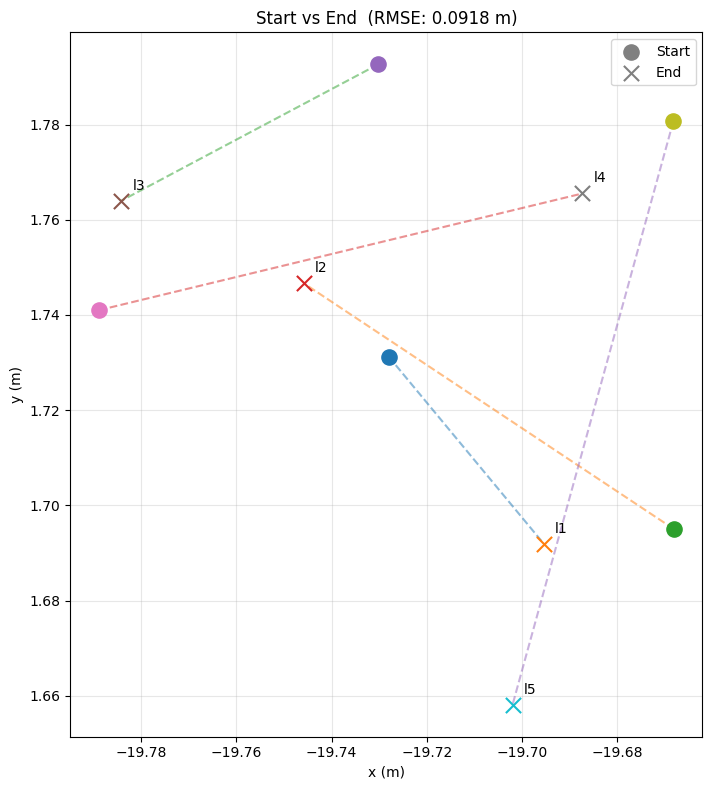

([np.float64(0.0026044028635792784),
  np.float64(0.00870281090660623),
  np.float64(0.003737685071643673),
  np.float64(0.010915664344617168),
  np.float64(0.01616827651983423)],
 np.float64(0.09179198190068735))

In [105]:
plot_start_vs_end(loop)